<a href="https://colab.research.google.com/github/tsilva/aiml-notebooks/blob/main/notebooks/wip-gymnasium-temporal-autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Train Gymnasium with Convolutional Autoencoders with a Bottleneck

## Setup

Install non-optional packages:

In [1]:
!pip install wandb datasets tsilva_notebook_utils==0.0.38

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.6 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
t

🔑 Loading API keys and authentication tokens from Colab secrets:

In [2]:
from tsilva_notebook_utils.colab import load_secrets_into_env

load_secrets_into_env([
    'WANDB_API_KEY',
    'NOTIFICATION_URL',
    'NOTIFICATION_AUTH_TOKEN'
])

['150cf7fd55e30189bacd411eb8c80e7fd065872a',
 'https://pleasing-foal-yearly.ngrok-free.app',
 '57c56029-095d-45af-85a1-a2d77d6ef3eb']

Define configuration:

In [48]:
import os
from tsilva_notebook_utils.colab import notebook_id_from_title

def setup_config():
    # @markdown ### 🏋️ Notebook Settings

    # @markdown Random seed used for reproducibility across runs
    seed = 42  # @param {type: "integer"}

    # @markdown ### 🗂️ Dataset Settings

    # @markdown Dataset ID to load gameplay recordings from
    # dataset_id = "tsilva/GymnasiumRecording__SuperMarioBros_Nes"  # @param {type: "string"}
    dataset_id = "tsilva/GymnasiumRecording__Tetris_GameBoy"  # @param {type: "string"}

    # @markdown Number of consecutive frames to stack as input
    frame_stack_size = 1  # @param {type: "number"}

    # @markdown Number of frames to skip between inputs
    frame_skip = 4  # @param {type: "number"}

    # @markdown Scale factor for input image resizing (e.g., 0.5 = half size)
    image_scale = 0.5  # @param {type: "number"}

    # @markdown Image mode used: grayscale, color, or black-and-white
    image_mode = "black_and_white"  # @param ["color", "grayscale", "black_and_white"]

    image_quantize_colors = 2 # @param {type: "number"}

    # @markdown Crop paddings (left, top, right, bottom) applied to input image
    image_crop_paddings = "0,64,0,16"  # @param {type: "string"}

    # @markdown Amount of random noise added to inputs during training
    image_noise_factor = 0  # @param {type: "number"}

    # @markdown ### 🧠 Model Settings

    # @markdown Dimensionality of the learned latent space
    latent_dim = 512  # @param {type: "number"}

    # @markdown Amount of noise to add to the latent representation (regularization)
    latent_noise_factor = 0.0  # @param {type: "number"}

    # @markdown Number of epochs between each validation run
    validation_epochs = 10  # @param {type: "number"}

    # @markdown ### 🏋️ Training Settings

    # @markdown Total number of training epochs
    n_epochs = 1000  # @param {type: "integer"}

    # @markdown Number of samples per training batch
    batch_size = 128  # @param {type: "integer"}

    # @markdown Maximum gradient norm for clipping (0 = no clipping)
    max_grad_norm = 0  # @param {type: "number"}

    # @markdown L2 weight decay added to the optimizer (0 = none)
    weight_decay = 0  # @param {type: "number"}

    # @markdown Proportion of total steps used for learning rate warmup
    warmup_ratio = 0  # @param {type: "number"}

    # @markdown Loss function to use (e.g., 'mse', 'mae')
    loss_function = "mse"

    # @markdown Weight for the sparsity loss component (helps compress representations)
    latent_sparsity_loss_alpha = 0.1  # @param {type: "number"}

    # @markdown Learning rate used by the optimizer
    learning_rate = 0.001  # @param {type: "number"}

    # Set notebook ID
    os.environ["NOTEBOOK_ID"] = notebook_id_from_title()

    return dict(
        # Notebook
        seed=seed,
        validation_epochs=validation_epochs,

        # Dataset
        dataset_id=dataset_id,
        frame_skip=frame_skip,
        frame_stack_size=frame_stack_size,
        image_scale=image_scale,
        image_mode=image_mode,
        image_quantize_colors=image_quantize_colors,
        image_crop_paddings=image_crop_paddings,
        image_noise_factor=image_noise_factor,

        # Model
        latent_dim=latent_dim,
        latent_noise_factor=latent_noise_factor,

        # Training
        n_epochs=n_epochs,
        batch_size=batch_size,
        max_grad_norm=max_grad_norm,
        weight_decay=weight_decay,
        warmup_ratio=warmup_ratio,
        loss_function=loss_function,
        learning_rate=learning_rate,
        latent_sparsity_loss_alpha=latent_sparsity_loss_alpha
    )

CONFIG = setup_config()

Enable cudnn benchmarking to select optimal cuda kernels:

In [4]:
#import torch
#torch.backends.cudnn.benchmark = True

Login to wandb:

In [5]:
from wandb import login
login()

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: tsilva to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

Load dataset:

In [6]:
from datasets import load_dataset
dataset = load_dataset(CONFIG["dataset_id"], split="train")
dataset

README.md:   0%|          | 0.00/386 [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/15.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/36054 [00:00<?, ? examples/s]

Dataset({
    features: ['episode_id', 'image', 'step', 'action'],
    num_rows: 36054
})

Deduplicate dataset:

In [7]:
from tsilva_notebook_utils.huggingface import dedupe_dataset
deduped_dataset = dedupe_dataset(dataset, "image")
deduped_dataset

Filter:   0%|          | 0/36054 [00:00<?, ? examples/s]

Dataset({
    features: ['episode_id', 'image', 'step', 'action'],
    num_rows: 5012
})

Show sample dataset image:

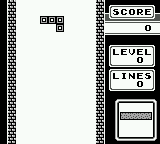

In [8]:
sample_image = dataset[0]["image"]
sample_image

Process image:

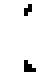

In [50]:
from tsilva_notebook_utils.huggingface import process_images
from torchvision.transforms.functional import to_pil_image

PROCESS_IMAGE_CONFIG = {
    "mode" : CONFIG["image_mode"],
    "quantize_colors" : CONFIG["image_quantize_colors"],
    "scale" : CONFIG["image_scale"],
    "crop_paddings" : [int(x) for x in CONFIG["image_crop_paddings"].split(",")],
    "noise_factor" : CONFIG["image_noise_factor"]
}
processed_image_t = process_images([sample_image], **PROCESS_IMAGE_CONFIG)[0]
processed_image = to_pil_image(processed_image_t)
processed_image

Retrieve image dimensions:

In [58]:
image_channels, image_height, image_width = processed_image_t.shape
image_channels, image_height, image_width

(1, 72, 40)

Add processed images to dataset:

In [52]:
def _map_process_images(batch):
    inputs = targets = process_images(batch["image"], **PROCESS_IMAGE_CONFIG)
    return dict(
        input=inputs,
        target=targets
    )
processed_dataset = deduped_dataset.map(
    _map_process_images,
    batched=True,
    batch_size=64
)

Map:   0%|          | 0/5012 [00:00<?, ? examples/s]

Create train and validation datasets (validation dataset only has every Nth frame, train dataset has all frames except those):

In [56]:
import torch
from torch.utils.data import DataLoader

frame_skip = CONFIG['frame_skip']
test_dataset = processed_dataset.remove_columns(['episode_id', 'image', 'step', 'action'])
test_dataset = test_dataset.with_format("torch")
mask = torch.arange(len(test_dataset)) % frame_skip == 0
train_dataset = test_dataset.select(torch.nonzero(~mask).squeeze()).with_format("torch")
validation_dataset = test_dataset.select(torch.nonzero(mask).squeeze()).with_format("torch")
train_dataset, validation_dataset

(Dataset({
     features: ['input', 'target'],
     num_rows: 3759
 }),
 Dataset({
     features: ['input', 'target'],
     num_rows: 1253
 }))

Create dataset loaders:

In [57]:
import multiprocessing

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    pin_memory=True,
    num_workers=multiprocessing.cpu_count(),
    prefetch_factor=4
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=CONFIG["batch_size"],
    pin_memory=True,
    shuffle=False,
    num_workers=multiprocessing.cpu_count(),
    prefetch_factor=4
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    pin_memory=True,
    shuffle=False,
    num_workers=multiprocessing.cpu_count()
)

Render validation loader to make sure to make sure everything is ok:

In [55]:
from tsilva_notebook_utils.video import render_loader_video
render_loader_video(validation_loader, scale=2)

Rendering frames: 100%|██████████| 10/10 [00:01<00:00,  9.11it/s]


Create the model:

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from datasets import load_dataset

class ConvAutoencoder(nn.Module):
    def __init__(self, input_channels, output_channels, input_height, input_width, latent_dim=None, use_fc=True):
        super(ConvAutoencoder, self).__init__()

        self.latent_noise_factor = CONFIG['latent_noise_factor']

        if latent_dim is None: latent_dim = CONFIG['latent_dim']
        self.use_fc = use_fc

        # --- Encoder ---
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(input_channels, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Dummy forward pass to compute shape
        with torch.no_grad():
            dummy_input = torch.zeros(1, input_channels, input_height, input_width)
            dummy_output = self.encoder_conv(dummy_input)
            self._flattened_size = dummy_output.numel()
            self._conv_output_shape = dummy_output.shape[1:]

        if self.use_fc:
            self.fc_enc = nn.Linear(self._flattened_size, latent_dim)
            self.fc_dec = nn.Linear(latent_dim, self._flattened_size)

        # --- Decoder ---
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, 2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(32, output_channels, 2, stride=2),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder_conv(x)
        if self.use_fc:
            x = x.view(x.size(0), -1)
            x = self.fc_enc(x)
        return x

    def decode(self, z):
        if self.use_fc:
            z = self.fc_dec(z)
            z = z.view(z.size(0), *self._conv_output_shape)
        else:
            z = z  # z already in conv shape
        z = self.decoder_conv(z)
        return z

    def forward(self, x):
        z = self.encode(x)

        # Add noise to latent space
        if self.training and self.latent_noise_factor > 0: # TODO: move to init
            noise = torch.randn_like(z) * self.latent_noise_factor
            z_noisy = z + noise
        else:
            z_noisy = z

        out = self.decode(z_noisy)
        return out, z

frame_stack_size = CONFIG['frame_stack_size']
latent_dim = CONFIG['latent_dim']
use_bottleneck = latent_dim > 0
input_channels = frame_stack_size * image_channels
output_channels = image_channels
model = ConvAutoencoder(input_channels, output_channels, image_height, image_width, use_bottleneck=use_bottleneck)
model

Create model, loss function and optimizer:

In [60]:
from tsilva_notebook_utils.torch import get_current_device

device = get_current_device()
model = ConvAutoencoder(input_channels, output_channels, image_height, image_width, use_bottleneck=use_bottleneck).to(device)
model = torch.compile(model)

if CONFIG['loss_function'] == 'mse':
    loss_fn = nn.MSELoss()
elif CONFIG['loss_function'] == 'ssim':
    from pytorch_msssim import MS_SSIM
    ms_ssim = MS_SSIM(data_range=1.0, size_average=True, channel=image_channels)
    loss_fn = lambda pred, target: 1 - ms_ssim(pred, target)

optimizer = optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"], fused=True)

NameError: name 'ConvAutoencoder' is not defined

Test a forward pass through the model to make sure shapes are accurate:

In [59]:
from tsilva_notebook_utils.plots import plot_embeddings_with_inputs

z_list = []
x_images = []
for batch in train_loader:
    x = batch["input"].to(device)
    with torch.no_grad(): y_pred, z = model(x)
    z_list.append(z.detach().cpu())
    x_images.extend([to_pil_image(_x) for _x in x.detach().cpu().unbind(0)])

z_all = torch.cat(z_list, dim=0)
z_latent_np = z_all.numpy()
plot_embeddings_with_inputs(z_latent_np, x_images)

NameError: name 'device' is not defined

In [ ]:
def log_heatmap(data, title, wandb_key):
    import matplotlib.pyplot as plt
    import numpy as np

    fig, ax = plt.subplots(figsize=(min(20, data.shape[1] * 0.4), 2.5))  # wider layout for long vectors
    im = ax.imshow(data, cmap='viridis', aspect='auto')

    # Annotate each cell
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, f'{data[i, j]:.2f}', ha='center', va='center', color='white', fontsize=7)

    # Ticks
    ax.set_xticks(np.arange(data.shape[1]))
    ax.set_yticks([])  # optional: hide y-axis if it's just 1 row

    ax.set_title(title)
    fig.tight_layout()
    wandb.log({wandb_key: wandb.Image(fig)})
    plt.close(fig)

Run training:

In [ ]:
import wandb
from tqdm import tqdm
import torch.optim as optim
from torch.nn.utils import clip_grad_norm_
from tsilva_notebook_utils.torch import calc_model_grad_norms

# Iterate over batches
from torch import autocast, GradScaler

import os
import wandb
from tqdm import tqdm
import torch
from torch import autocast
from torch.amp import GradScaler
from torch.nn.utils import clip_grad_norm_

def train(
    model,
    loss_fn,
    optimizer,
    train_loader,
    n_epochs=None,
    eval_fn=None,
    learning_rate=None,
    max_grad_norm=None,
    warmup_ratio=None
):
    NOTEBOOK_ID = os.getenv("NOTEBOOK_ID")
    assert NOTEBOOK_ID is not None, "NOTEBOOK_ID environment variable is not set"

    with wandb.init(project=NOTEBOOK_ID, config=CONFIG) as run:
        n_epochs = n_epochs or CONFIG['n_epochs']
        learning_rate = learning_rate or CONFIG['learning_rate']
        max_grad_norm = max_grad_norm or CONFIG['max_grad_norm']
        warmup_ratio = warmup_ratio or CONFIG['warmup_ratio']

        device = next(model.parameters()).device
        scaler = GradScaler('cuda')
        wandb.watch(model, log="all")

        total_steps = n_epochs * len(train_loader)
        warmup_steps = int(warmup_ratio * total_steps)

        def lr_lambda(step):
            return float(step) / float(max(1, warmup_steps)) if step < warmup_steps else 1.0

        scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

        global_step = 0
        latent_epsilon = 1e-6

        with tqdm(range(n_epochs), desc="Training") as pbar:
            for epoch in pbar:
                model.train()
                losses, all_zs = [], []

                for batch in train_loader:
                    x_batch = batch["input"].to(device)
                    y_batch = batch["target"].to(device)

                    optimizer.zero_grad()
                    global_step += 1

                    with autocast('cuda'):
                        logits, z = model(x_batch)
                        all_zs.append(z.detach().cpu())

                        reconstruction_loss = loss_fn(logits, y_batch)
                        sparsity_loss = CONFIG['sparsity_loss_alpha'] * torch.mean(torch.abs(z)) if CONFIG['sparsity_loss_alpha'] > 0 else 0
                        loss = reconstruction_loss + sparsity_loss

                        losses.append(loss.item())

                    scaler.scale(loss).backward()

                    if max_grad_norm:
                        scaler.unscale_(optimizer)
                        clip_grad_norm_(model.parameters(), max_grad_norm)

                    scaler.step(optimizer)
                    scaler.update()
                    scheduler.step()

                model.eval()
                val_loss = None
                if epoch % CONFIG['validation_epochs'] == 0:
                    val_losses = []
                    for batch in validation_loader:
                        x_batch = batch["input"].to(device)
                        y_batch = batch["target"].to(device)
                        with torch.no_grad():
                            logits, z = model(x_batch)
                            val_losses.append(loss_fn(logits, y_batch).item())
                    val_loss = sum(val_losses) / len(val_losses)

                #z_all = torch.cat(all_zs, dim=0).view(-1)
                z_all = torch.cat(all_zs, dim=0)  # shape: [total_samples, latent_dim]

                activation_rate = (z_all.abs() > latent_epsilon).float().mean(dim=0)


                wandb_stats = {
                    'meta/epoch': epoch + 1,
                    'meta/step': global_step,
                    'meta/learning_rate': scheduler.get_last_lr()[0],
                    'train/loss': sum(losses) / len(losses),
                    'train/reconstruction_loss': reconstruction_loss.item(),
                    'train/sparsity_loss': sparsity_loss.item() if CONFIG['sparsity_loss_alpha'] > 0 else 0,
                    'latent_z/sparsity': (z_all.abs() < latent_epsilon).float().mean().item(),
                    'latent_z/active_ratio': (z_all.abs() > latent_epsilon).float().mean().item(),
                    'latent_z/min': z_all.min().item(),
                    'latent_z/max': z_all.max().item(),
                    'latent_z/mean': z_all.mean().item(),
                    'latent_z/std': z_all.std().item(),
                    'latent_z/l2_norm': z_all.norm(p=2).item(),
                    'latent_z/l1_norm': z_all.norm(p=1).item(),
                    'latent_z/hist': wandb.Histogram(z_all.numpy()),
                    'latent_z/activation_per_dim': wandb.Histogram(activation_rate.cpu().numpy())
                }

                # all_zs is a list of tensors with shape [batch_size, latent_dim]
                # Stack them so shape is [num_batches, batch_size, latent_dim]
                #z_batched = torch.stack(all_zs)  # shape: [num_batches, batch_size, latent_dim]

                # Compute batch-level mean and median of z
                #batch_means = z_batched.mean(dim=1)   # shape: [num_batches, latent_dim]
                #batch_medians = z_batched.median(dim=1).values  # shape: [num_batches, latent_dim]

                # Now average across batches to get final [1, latent_dim]
                #mean_z = batch_means.mean(dim=0, keepdim=True).cpu().numpy()
                #median_z = batch_medians.median(dim=0).values.unsqueeze(0).cpu().numpy()

                #log_heatmap(mean_z, "Mean of z across batch", "latent_z/mean_heatmap")
                #log_heatmap(median_z, "Median of z across batch", "latent_z/median_heatmap")

                pbar_stats = {
                    'epoch': epoch + 1,
                    'train_loss': f'{wandb_stats["train/loss"]:.4f}',
                    'lr': f'{wandb_stats["meta/learning_rate"]:.6e}'
                }

                if eval_fn:
                    eval_results = eval_fn()
                    wandb_stats['val/loss'] = eval_results['loss']
                    wandb_stats['val/accuracy'] = eval_results['accuracy']
                    pbar_stats['val_acc'] = f'{eval_results["accuracy"] * 100:.2f}%'

                wandb.log(wandb_stats, step=global_step)
                pbar.set_postfix(pbar_stats)

        return run

train(model, loss_fn, optimizer, train_loader)

In [ ]:
import tempfile
from tsilva_notebook_utils.video import save_frames_to_dir, render_video_from_dir

latents = []
for batch in test_loader:
  x_batch = batch["input"].to(device)
  with torch.no_grad():
    z = model.encode(x_batch)
    latents.append(z.detach().cpu())
latents = torch.cat(latents)
n_samples = latents.shape[0]
print(latents.shape)
mean = latents.mean(dim=0)
cov = torch.cov(latents.T)  # Note: PyTorch 2.0+ has torch.cov

# Sampling from multivariate normal in PyTorch:
mvn = torch.distributions.MultivariateNormal(mean, covariance_matrix=cov)
samples = mvn.sample((1000,)).to(device)
with torch.no_grad(): decoded = model.decode(samples)
frames_t = decoded.unbind(0)

latent_dim = CONFIG['latent_dim']
with tempfile.TemporaryDirectory() as temp_dir:
    save_frames_to_dir(frames_t, temp_dir)
    video = render_video_from_dir(temp_dir, fps=10, scale=2)
video

In [ ]:
from sklearn.decomposition import PCA

latents_np = latents.numpy()
latent_dim = CONFIG['latent_dim']
pca = PCA(n_components=latent_dim)
latents_pca = pca.fit_transform(latents_np)

# Sample along the top 2 PCA directions
t = torch.linspace(-3, 3, steps=100)
samples_pca = []
for i in range(len(t)):
    point = torch.tensor(pca.mean_) + t[i] * torch.tensor(pca.components_[0])
    samples_pca.append(point)
samples = torch.stack(samples_pca).to(device)

with torch.no_grad(): decoded = model.decode(samples)
frames_t = decoded.unbind(0)

with tempfile.TemporaryDirectory() as temp_dir:
    save_frames_to_dir(frames_t, temp_dir)
    video = render_video_from_dir(temp_dir, fps=10, scale=2)
video

In [ ]:
import tempfile
from tsilva_notebook_utils.video import save_frames_to_dir, render_video_from_dir

latent_dim = CONFIG['latent_dim']
with tempfile.TemporaryDirectory() as temp_dir:
    frames = []
    for i in range(latent_dim):
        encoded = torch.zeros(latent_dim, device=device)
        encoded[i] = 1.0
        encoded = encoded.unsqueeze(0)  # shape: (1, latent_dim)
        decoded = model.decode(encoded)
        frames.append(decoded.squeeze())
    save_frames_to_dir(frames, temp_dir)
    video = render_video_from_dir(temp_dir, fps=10, scale=2)
video

In [ ]:
from tsilva_notebook_utils.video import save_frames_to_dir, render_video_from_dir
import torch.nn.functional as F
import random

latent_dim = CONFIG['latent_dim']
sparsity_ratio = 0.05  # Match your model's average sparsity
num_frames = latent_dim  # or choose more/less depending on what you want to visualize

with tempfile.TemporaryDirectory() as temp_dir:
    frames = []
    for _ in range(num_frames):
        # Start with all zeros
        encoded = torch.zeros(latent_dim, device=device)

        # Randomly activate a sparse subset
        n_active = int(latent_dim * sparsity_ratio)
        active_indices = random.sample(range(latent_dim), n_active)

        # Assign random values (or fixed if you want consistency)
        encoded[active_indices] = torch.rand(n_active, device=device)

        # Decode and save frame
        decoded = model.decode(encoded.unsqueeze(0))
        frame = decoded.squeeze().detach().cpu()
        frames.append(frame)

    save_frames_to_dir(frames, temp_dir)
    video = render_video_from_dir(temp_dir, fps=10, scale=2)

video

Render video of autoencoder predictions:

In [ ]:
from tsilva_notebook_utils.video import render_autoencoder_video
render_autoencoder_video(model, validation_loader, fps=10, scale=2)

⏰ Setting up auto-notification and resource management:

In [ ]:
from tsilva_notebook_utils.colab import notify_and_disconnect_after_timeout
notify_and_disconnect_after_timeout()